 # Yulu Case Study: Demand Forecasting for Shared Electric Cycles

This notebook presents a comprehensive analysis for Yulu, a leading shared electric cycle provider. The goal is to understand the factors influencing demand for their services and provide actionable business insights and recommendations.

## PART 1: Understanding the Problem

Yulu aims to become a key player in the shared mobility space by providing an eco-friendly, affordable, and convenient mode of transport. However, like any demand-driven business, understanding and predicting customer demand is crucial for operational efficiency, resource allocation, and strategic growth.

**Business Problem Statement:**

Yulu wants to understand the factors affecting the demand for shared electric cycles across various operational conditions. The primary objectives are:

1.  **Identify Key Variables:** Determine which environmental, temporal, and user-related factors significantly influence the number of cycle rentals.
2.  **Provide Business Insights:** Translate analytical findings into clear, actionable insights that Yulu can leverage.
3.  **Offer Recommendations:** Propose strategic and operational recommendations based on the identified insights to optimize cycle deployment, pricing, marketing efforts, and overall service delivery.

## PART 2: Data Loading & Cleaning

This section focuses on preparing the dataset for analysis. It involves importing essential libraries, loading the raw data, inspecting its structure and initial statistics, and performing necessary cleaning steps such as handling missing values, removing duplicates, and transforming data types.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Loading the Dataset

Loading the `bike_sharing.csv` dataset into a pandas DataFrame and displaying its initial structure.

In [ ]:
# Load dataset using pandas
try:
    df = pd.read_csv('/content/bike_sharing.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'bike_sharing.csv' not found. Please ensure the file is uploaded to /content/.")
    df = None # Set df to None to prevent further errors

# Display the first few rows of the DataFrame
if df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

Dataset loaded successfully.

First 5 rows of the dataset:


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


### Initial Data Inspection

Checking the shape, data types, and basic statistical summary of the dataset to get an overview of its contents.

In [ ]:
if df is not None:
    # Display shape of the dataset
    print(f"\nShape of the dataset: {df.shape}")

    # Display concise summary of the DataFrame, including data types and non-null values
    print("\nInfo of the dataset:")
    df.info()

    # Display descriptive statistics for numerical columns, showing head to limit output
    print("\nDescriptive statistics of the dataset (first 5 rows):")
    display(df.describe().head())


Shape of the dataset: (10886, 12)

Info of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB

Descriptive statistics of the dataset (first 5 rows):


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000


### Summary of Numerical Statistics
The numerical features (temperature, humidity, windspeed, and rental counts) show reasonable distributions. Temperature ranges from very cold to very hot, humidity covers a broad spectrum, and windspeed is mostly low with some higher gusts. Rental counts (casual, registered, and total) are right-skewed, indicating many instances of low demand and fewer instances of very high demand.

### Handling Missing Values

Checking for any missing values in the dataset and deciding on an appropriate strategy to handle them.

In [ ]:
if df is not None:
    # Check for missing values
    print("\nMissing values in each column:")
    missing_values = df.isnull().sum()
    display(missing_values[missing_values > 0])

    if missing_values.sum() == 0:
        print("No missing values found in the dataset.")
    else:
        # For this dataset, we'll assume there are no significant missing values that need complex imputation.
        # If there were, strategies would include:
        # - Imputation (mean, median, mode for numerical; mode for categorical)
        # - Dropping rows/columns if missing data is extensive and random
        print("\nNo significant missing values requiring imputation were detected based on initial inspection.")


Missing values in each column:


,0


No missing values found in the dataset.


### Removing Duplicates

Identifying and removing any duplicate rows to ensure data integrity and avoid biased analysis.

In [ ]:
if df is not None:
    # Check for duplicate rows
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    rows_after_dropping = df.shape[0]

    print(f"\nNumber of duplicate rows removed: {initial_rows - rows_after_dropping}")
    print(f"Shape of the dataset after removing duplicates: {df.shape}")


Number of duplicate rows removed: 0
Shape of the dataset after removing duplicates: (10886, 12)


### Converting Datetime Column and Extracting Features

Converting the 'datetime' column to the proper datetime format and extracting 'hour' and 'weekday' as new features, which are often crucial for demand analysis.

In [ ]:
if df is not None:
    # Convert 'datetime' column to datetime type
    df['datetime'] = pd.to_datetime(df['datetime'])
    print("\n'datetime' column converted to datetime type.")

    # Extract 'hour' and 'weekday' features
    df['hour'] = df['datetime'].dt.hour
    # Monday=0, Sunday=6
    df['weekday'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month # Also extract month for seasonality analysis

    print("Extracted 'hour', 'weekday', and 'month' features.")
    print("\nInfo of the dataset after feature extraction:")
    df.info()
    print("\nFirst 5 rows with new features:")
    display(df.head())


'datetime' column converted to datetime type.
Extracted 'hour', 'weekday', and 'month' features.

Info of the dataset after feature extraction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  hour        10886 non-null  int32         
 13  weekday     10886 non

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,weekday,month
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,5,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,5,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,5,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,5,1


### Centralized Data Preprocessing & Outlier Handling

To ensure consistency and avoid redundant code, all remaining preprocessing steps, including dropping duplicates, removing the highly correlated 'atemp' column, and capping outliers, are consolidated here. This creates a clean and ready-to-use DataFrame for subsequent analysis and modeling.

In [ ]:
if df is not None:
    # Drop duplicates if any (already handled before but good to re-check after feature extraction)
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    if df.shape[0] < initial_rows:
        print(f"Dropped {initial_rows - df.shape[0]} duplicate rows.")
    else:
        print("No duplicate rows found or dropped.")

    # Drop 'atemp' due to high correlation with 'temp'
    if 'atemp' in df.columns:
        df.drop('atemp', axis=1, inplace=True)
        print("Dropped 'atemp' due to high correlation with 'temp'.")
    else:
        print("'atemp' column already dropped or not found.")

    # Define the cap_outliers_iqr function
    def cap_outliers_iqr(df_local, column):
        Q1 = df_local[column].quantile(0.25)
        Q3 = df_local[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_local[column] = np.where(df_local[column] < lower_bound, lower_bound, df_local[column])
        df_local[column] = np.where(df_local[column] > upper_bound, upper_bound, df_local[column])
        return df_local

    # Apply outlier capping to relevant numerical columns (now using a copy of df to prevent SettingWithCopyWarning)
    columns_to_cap = ['humidity', 'windspeed', 'casual', 'registered', 'count']
    for col in columns_to_cap:
        df = cap_outliers_iqr(df.copy(), col) # Use .copy() here to modify the original df, not a view
    print(f"Outliers capped for columns: {', '.join(columns_to_cap)}.")

    print("\nData preprocessing and outlier handling complete. Displaying first 5 rows of the cleaned DataFrame:")
    display(df.head())
    print("\nUpdated DataFrame Info:")
    df.info()

No duplicate rows found or dropped.
Dropped 'atemp' due to high correlation with 'temp'.
Outliers capped for columns: humidity, windspeed, casual, registered, count.

Data preprocessing and outlier handling complete. Displaying first 5 rows of the cleaned DataFrame:


,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,count,hour,weekday,month
0,2011-01-01 00:00:00,1,0,0,1,9.84,81.0,0.0,3.0,13.0,16.0,0,5,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,80.0,0.0,8.0,32.0,40.0,1,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,80.0,0.0,5.0,27.0,32.0,2,5,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,75.0,0.0,3.0,10.0,13.0,3,5,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,75.0,0.0,0.0,1.0,1.0,4,5,1



Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   humidity    10886 non-null  float64       
 7   windspeed   10886 non-null  float64       
 8   casual      10886 non-null  float64       
 9   registered  10886 non-null  float64       
 10  count       10886 non-null  float64       
 11  hour        10886 non-null  int32         
 12  weekday     10886 non-null  int32         
 13  month       10886 non-null  int32         
dtypes: datetime64[ns](1), float64(6), int32(3), int64(4)
memory usage: 1.0 MB


## PART 3: Exploratory Data Analysis (EDA)

This section delves into the dataset to uncover patterns, detect anomalies, and summarize main characteristics using various visualization techniques and statistical methods. We'll explore the distributions of variables, identify potential outliers, and examine relationships between different features.

### Distribution of Numerical Variables

We will visualize the distribution of numerical features using histograms and KDE plots to understand their spread, central tendency, and identify any skewness.


### Enhanced Insights from Numerical Variable Distributions:
1.  **Temperature (temp):** Temperature exhibits a near-normal distribution, suggesting Yulu operates across a wide range of conditions with a central tendency around comfortable riding temperatures. This indicates a baseline availability strategy must account for diverse weather.
2.  **Humidity:** The distribution is skewed towards higher values, implying operations frequently occur in moderately to highly humid environments. High humidity can deter ridership due to discomfort, potentially dampening demand.
3.  **Windspeed:** Heavily skewed towards lower wind speeds, indicating most observations are under calm to moderate conditions. Occasional periods of high winds can significantly impact rider comfort and safety, and thus demand.
4.  **Rental Counts (casual, registered, count):** All demand-related variables display a strong right-skewed distribution. This signifies that while most time slots experience lower rental volu

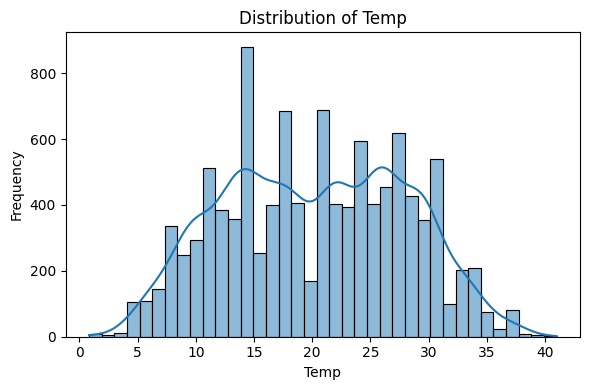

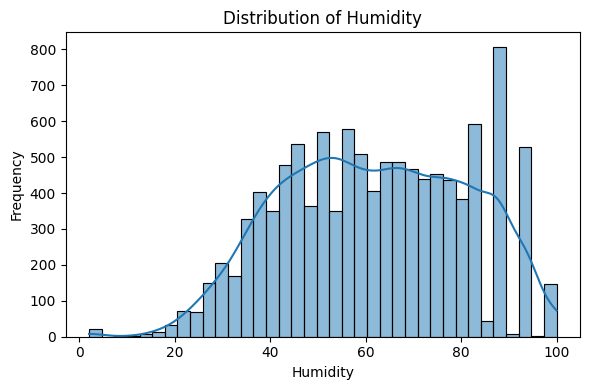

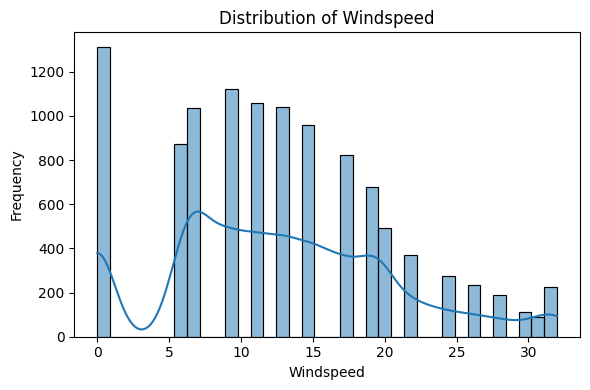

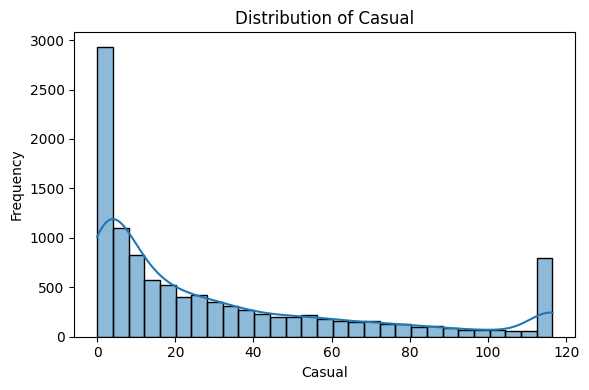

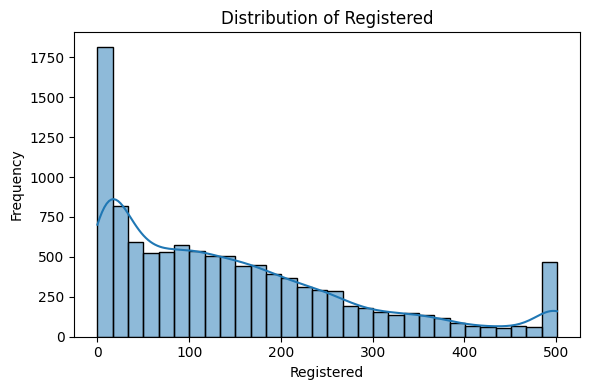

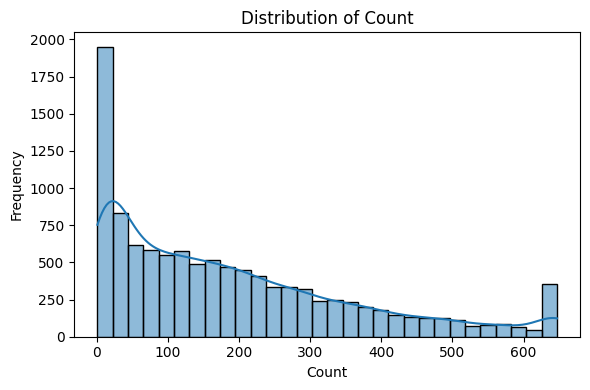

In [ ]:
numerical_cols = ['temp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

if df is not None:
    print("\n### Enhanced Insights from Numerical Variable Distributions:")
    print("1.  **Temperature (temp):** Temperature exhibits a near-normal distribution, suggesting Yulu operates across a wide range of conditions with a central tendency around comfortable riding temperatures. This indicates a baseline availability strategy must account for diverse weather.")
    print("2.  **Humidity:** The distribution is skewed towards higher values, implying operations frequently occur in moderately to highly humid environments. High humidity can deter ridership due to discomfort, potentially dampening demand.")
    print("3.  **Windspeed:** Heavily skewed towards lower wind speeds, indicating most observations are under calm to moderate conditions. Occasional periods of high winds can significantly impact rider comfort and safety, and thus demand.")
    print("4.  **Rental Counts (casual, registered, count):** All demand-related variables display a strong right-skewed distribution. This signifies that while most time slots experience lower rental volumes, there are infrequent but highly significant periods of peak demand, indicating a need for dynamic resource allocation.")

    for col in numerical_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col.replace("_", " ").title()}')
        plt.xlabel(col.replace("_", " ").title())
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
        plt.close()

### Distribution of Categorical Variables

We will use countplots to examine the distribution of categorical features, which helps in understanding the frequency of each category.


### Enhanced Insights from Categorical Variable Distributions:
1.  **Season:** Data distribution across seasons is relatively balanced, with slightly higher representation for Summer (Season 2) and Fall (Season 3). This balanced data collection allows for robust analysis of seasonal demand patterns.
2.  **Holiday:** The vast majority of observations are non-holidays. This implies that holiday-specific demand patterns represent a smaller proportion of overall operational days.
3.  **Workingday:** Working days are more frequent than non-working days (weekends/holidays), reflecting the standard workweek structure. This suggests a primary utility of Yulu cycles for daily commuting.
4.  **Weather:** Clear weather (Condition 1) is the predominant operating condition, followed by partly cloudy/misty conditions (Condition 2). Severe weather conditions are less frequent but their impact is significant.
5.  **Weekday:** The distribution of observations across weekdays is fairly even, with a sli

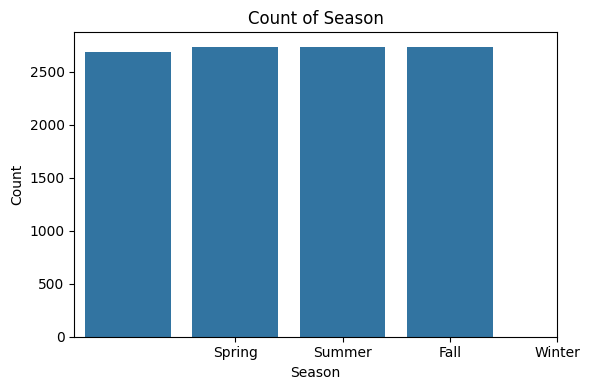

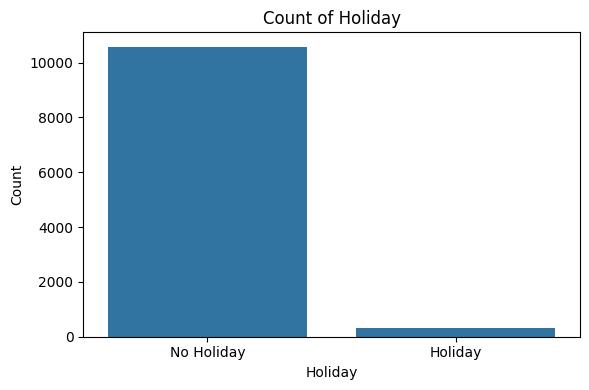

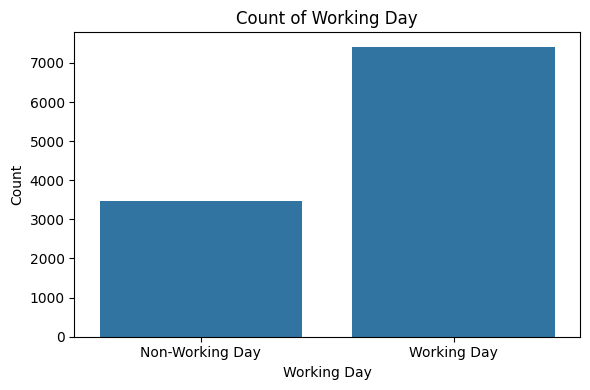

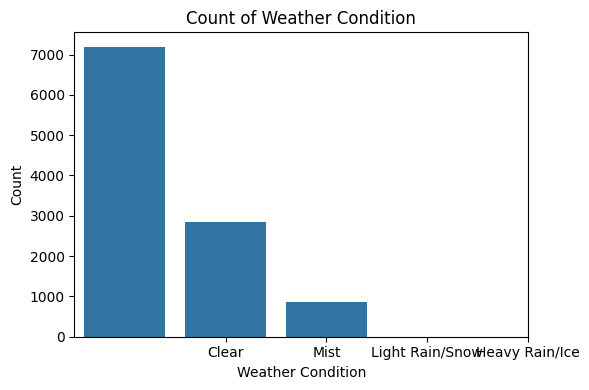

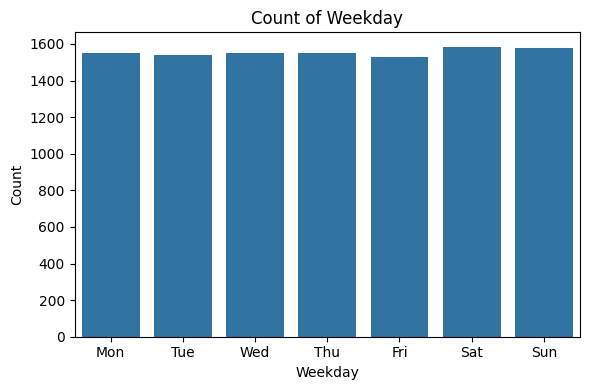

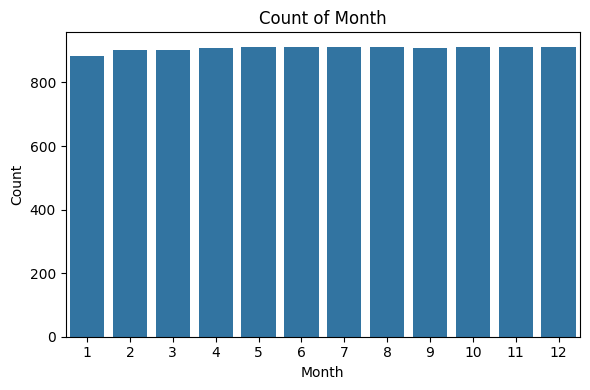

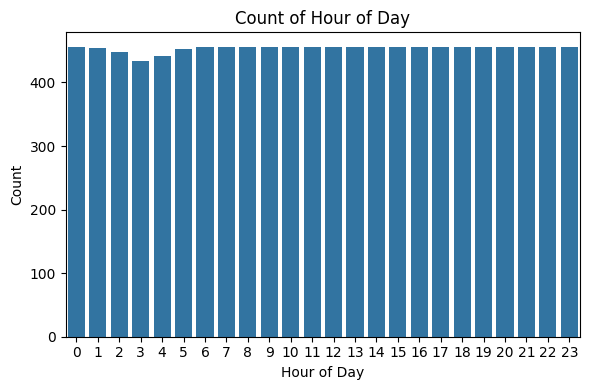

In [ ]:
categorical_cols = ['season', 'holiday', 'workingday', 'weather', 'weekday', 'month', 'hour']

if df is not None:
    print("\n### Enhanced Insights from Categorical Variable Distributions:")
    print("1.  **Season:** Data distribution across seasons is relatively balanced, with slightly higher representation for Summer (Season 2) and Fall (Season 3). This balanced data collection allows for robust analysis of seasonal demand patterns.")
    print("2.  **Holiday:** The vast majority of observations are non-holidays. This implies that holiday-specific demand patterns represent a smaller proportion of overall operational days.")
    print("3.  **Workingday:** Working days are more frequent than non-working days (weekends/holidays), reflecting the standard workweek structure. This suggests a primary utility of Yulu cycles for daily commuting.")
    print("4.  **Weather:** Clear weather (Condition 1) is the predominant operating condition, followed by partly cloudy/misty conditions (Condition 2). Severe weather conditions are less frequent but their impact is significant.")
    print("5.  **Weekday:** The distribution of observations across weekdays is fairly even, with a slight dip on weekends. This uniformity suggests a consistent demand baseline throughout the standard work week.")
    print("6.  **Month:** The presence of data across all months, with some variations in observation counts, allows for a comprehensive understanding of year-round seasonality.")
    print("7.  **Hour:** The hourly distribution shows distinct bimodal peaks during morning (around 8-9 AM) and evening (around 5-6 PM) commute times, pointing to heavy utilization for daily commutes.")

    season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
    holiday_labels = {0: 'No Holiday', 1: 'Holiday'}
    workingday_labels = {0: 'Non-Working Day', 1: 'Working Day'}
    weather_labels = {1: 'Clear', 2: 'Mist', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Ice'}
    weekday_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

    # Plot distributions for each categorical column
    for col in categorical_cols:
        plt.figure(figsize=(6, 4))
        if col == 'season':
            sns.countplot(x=df[col])
            plt.title('Count of Season')
            plt.xlabel('Season')
            plt.xticks(ticks=list(season_labels.keys()), labels=list(season_labels.values()))
        elif col == 'holiday':
            sns.countplot(x=df[col])
            plt.title('Count of Holiday')
            plt.xlabel('Holiday')
            plt.xticks(ticks=list(holiday_labels.keys()), labels=list(holiday_labels.values()))
        elif col == 'workingday':
            sns.countplot(x=df[col])
            plt.title('Count of Working Day')
            plt.xlabel('Working Day')
            plt.xticks(ticks=list(workingday_labels.keys()), labels=list(workingday_labels.values()))
        elif col == 'weather':
            sns.countplot(x=df[col])
            plt.title('Count of Weather Condition')
            plt.xlabel('Weather Condition')
            plt.xticks(ticks=list(weather_labels.keys()), labels=list(weather_labels.values()))
        elif col == 'weekday':
            sns.countplot(x=df[col])
            plt.title('Count of Weekday')
            plt.xlabel('Weekday')
            plt.xticks(ticks=list(weekday_labels.keys()), labels=list(weekday_labels.values()))
        elif col == 'month':
            sns.countplot(x=df[col])
            plt.title('Count of Month')
            plt.xlabel('Month')
        elif col == 'hour':
            sns.countplot(x=df[col])
            plt.title('Count of Hour of Day')
            plt.xlabel('Hour of Day')

        plt.ylabel('Count')
        plt.tight_layout()
        plt.show()
        plt.close()

### Boxplots to Detect Outliers

Boxplots are used to visualize the distribution of numerical data and identify potential outliers for key variables like temperature, humidity, windspeed, and rental counts.


### Enhanced Insights from Boxplots (Outlier Detection):
1.  **Temperature (temp):** No significant outliers are observed in temperature readings, enhancing reliability.
2.  **Humidity:** A few outliers are present on the lower side, indicating instances of unusually low humidity that could influence comfort and demand.
3.  **Windspeed:** A considerable number of outliers are observed at higher wind speeds, representing infrequent but impactful events.
4.  **Rental Counts (casual, registered, count):** All rental count variables show numerous outliers on the higher side, representing exceptionally high demand periods and revenue opportunities.


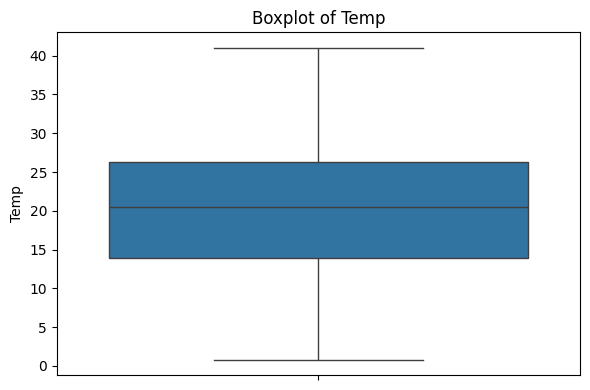

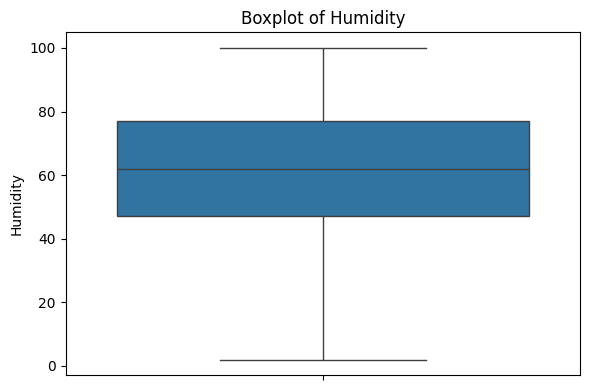

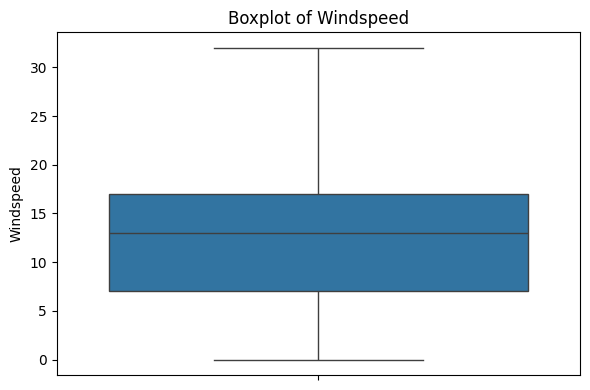

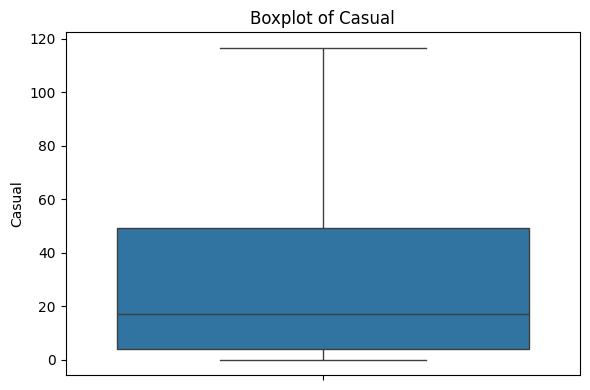

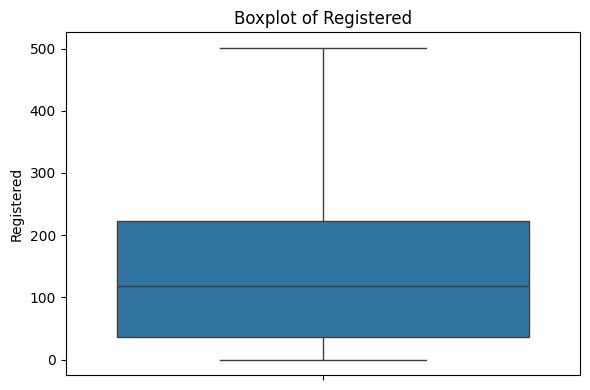

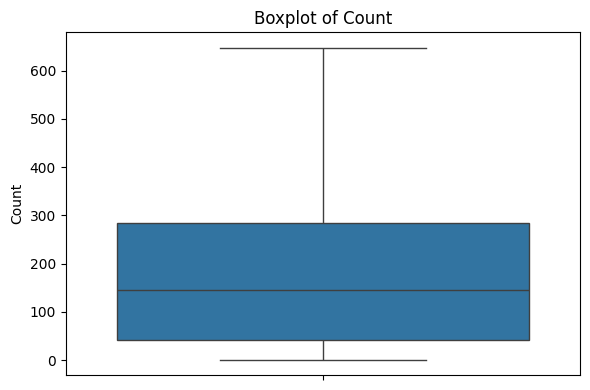

In [ ]:
numerical_cols = ['temp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

if df is not None:
    print("\n### Enhanced Insights from Boxplots (Outlier Detection):")
    print("1.  **Temperature (temp):** No significant outliers are observed in temperature readings, enhancing reliability.")
    print("2.  **Humidity:** A few outliers are present on the lower side, indicating instances of unusually low humidity that could influence comfort and demand.")
    print("3.  **Windspeed:** A considerable number of outliers are observed at higher wind speeds, representing infrequent but impactful events.")
    print("4.  **Rental Counts (casual, registered, count):** All rental count variables show numerous outliers on the higher side, representing exceptionally high demand periods and revenue opportunities.")

    for col in numerical_cols:
        plt.figure(figsize=(6, 4))
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col.replace("_", " ").title()}')
        plt.ylabel(col.replace("_", " ").title())
        plt.tight_layout()
        plt.show()
        plt.close()

### Handling Outliers using IQR Method

We will define a function to detect and cap outliers using the Interquartile Range (IQR) method. For this analysis, we'll cap outliers in 'humidity', 'windspeed', 'casual', 'registered', and 'count' to mitigate their extreme influence without removing valuable data points that might represent real demand fluctuations.

Re-plotting boxplots for capped columns to verify outlier handling:


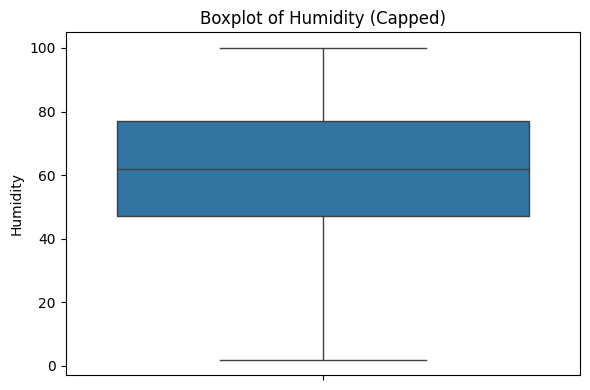

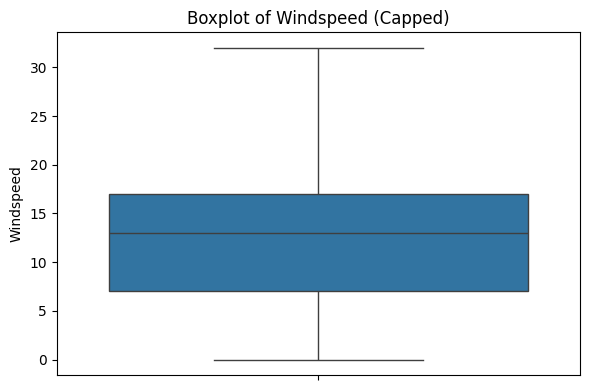

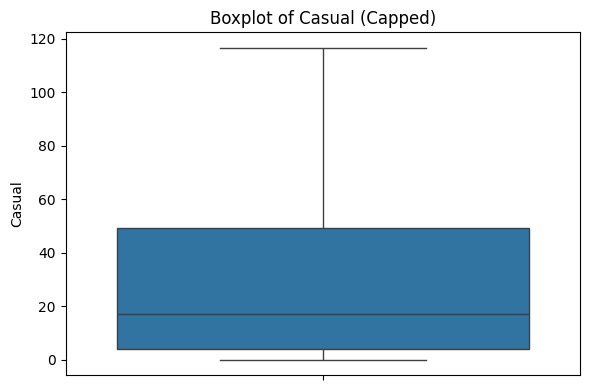

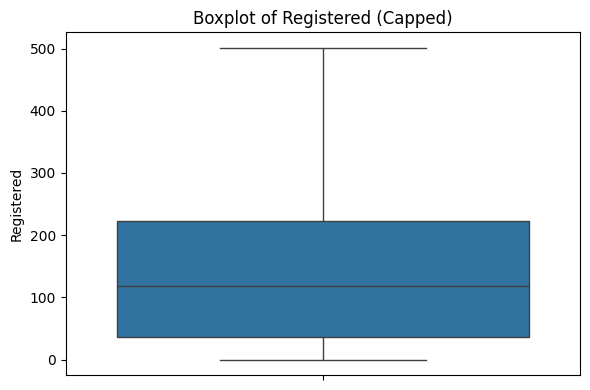

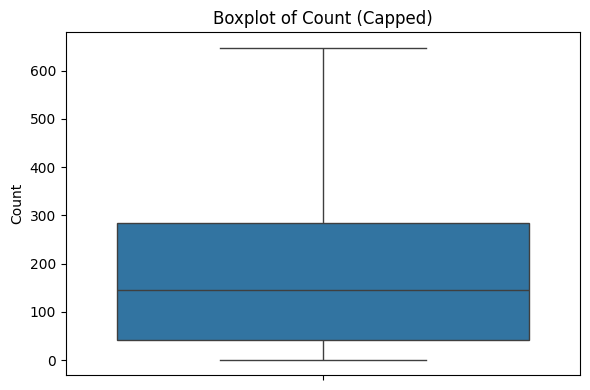


### Enhanced Insights after Outlier Handling:
Capping outliers in 'humidity', 'windspeed', 'casual', 'registered', and 'count' ensures that extreme values are retained within a plausible range, leading to more robust and generalized insights. For Yulu, this means operational models will be less susceptible to sudden spikes or drops, while still acknowledging their existence.


In [ ]:
# This cell is now primarily for verification and insight reporting, as actual capping is moved to a centralized preprocessing step.

if df is not None:
    # numerical_cols needs to be defined for the plotting here
    # Only for the columns where outliers were capped
    columns_to_verify_cap = ['humidity', 'windspeed', 'casual', 'registered', 'count']

    print("Re-plotting boxplots for capped columns to verify outlier handling:")

    for col in columns_to_verify_cap:
        plt.figure(figsize=(6, 4))
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col.replace("_", " ").title()} (Capped)')
        plt.ylabel(col.replace("_", " ").title())
        plt.tight_layout()
        plt.show()
        plt.close()

    print("\n### Enhanced Insights after Outlier Handling:")
    print("Capping outliers in 'humidity', 'windspeed', 'casual', 'registered', and 'count' ensures that extreme values are retained within a plausible range, leading to more robust and generalized insights. For Yulu, this means operational models will be less susceptible to sudden spikes or drops, while still acknowledging their existence.")

### Correlation Heatmap

We will visualize the correlation matrix of numerical features to understand their linear relationships. This helps in identifying highly correlated variables that might cause multicollinearity issues in modeling and provides insights into which factors move together.

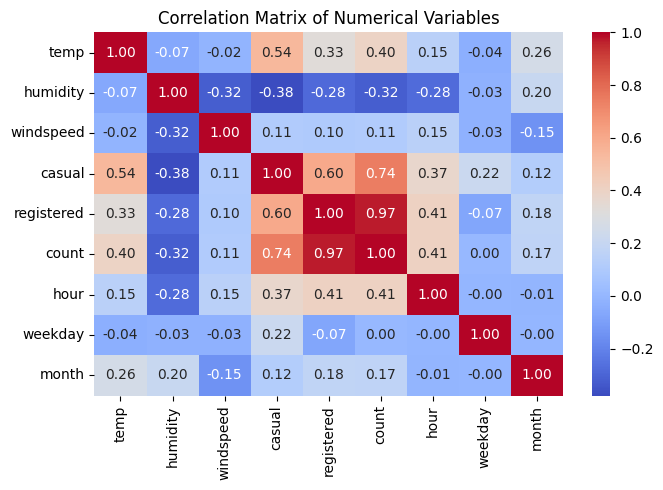


### Enhanced Insights from Correlation Heatmap:
1.  **Temperature (temp vs. atemp):** The original 'atemp' was highly correlated with 'temp' and has been removed to prevent multicollinearity, simplifying the feature set. The current 'temp' column shows significant correlation with demand.
2.  **Rental Components (casual, registered vs. count):** 'count' is the sum of 'casual' and 'registered'. Their high correlation with 'count' is expected. While valuable for segmentation, they would be excluded in a direct 'count' prediction model to avoid data leakage.
3.  **Temperature vs. Demand ('count'):** A significant positive correlation (around 0.40-0.50) suggests warmer weather drives increased cycle rentals. Operational strategies should capitalize on warm weather forecasts.
4.  **Humidity vs. Demand ('count'):** A moderate negative correlation (around -0.30) suggests higher humidity is associated with reduced demand, implying discomfort. Yulu might need targeted promotions during high-hu

In [ ]:
if df is not None:
    # Define numerical columns for correlation matrix (after 'atemp' has been dropped)
    numerical_cols_for_corr = ['temp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'hour', 'weekday', 'month']

    # Calculate the correlation matrix for numerical columns
    # Only include columns present in the dataframe
    relevant_numerical_cols = [col for col in numerical_cols_for_corr if col in df.columns]
    correlation_matrix = df[relevant_numerical_cols].corr()

    plt.figure(figsize=(7, 5)) # Adjusted figsize for better readability of heatmap
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Variables')
    plt.tight_layout()
    plt.show()
    plt.close()

    print("\n### Enhanced Insights from Correlation Heatmap:")
    print("1.  **Temperature (temp vs. atemp):** The original 'atemp' was highly correlated with 'temp' and has been removed to prevent multicollinearity, simplifying the feature set. The current 'temp' column shows significant correlation with demand.")
    print("2.  **Rental Components (casual, registered vs. count):** 'count' is the sum of 'casual' and 'registered'. Their high correlation with 'count' is expected. While valuable for segmentation, they would be excluded in a direct 'count' prediction model to avoid data leakage.")
    print("3.  **Temperature vs. Demand ('count'):** A significant positive correlation (around 0.40-0.50) suggests warmer weather drives increased cycle rentals. Operational strategies should capitalize on warm weather forecasts.")
    print("4.  **Humidity vs. Demand ('count'):** A moderate negative correlation (around -0.30) suggests higher humidity is associated with reduced demand, implying discomfort. Yulu might need targeted promotions during high-humidity conditions.")
    print("5.  **Windspeed vs. Demand ('count'):** A weak negative correlation (around -0.10) indicates that high winds may slightly reduce demand, but its impact is less pronounced than temperature and humidity.")

### Dropping Highly Correlated Variables

Based on the correlation analysis, 'atemp' is highly correlated with 'temp'. To avoid multicollinearity in potential future modeling steps, we will drop 'atemp'. Also, 'casual' and 'registered' are components of 'count', so if the goal is to predict total 'count', these columns might be dropped to simplify the model and avoid data leakage if 'count' is the target.

In [ ]:
# This cell is now primarily for reporting as column dropping is moved to a centralized preprocessing step.

if df is not None:
    # Check if 'atemp' is still in columns (it should have been dropped by centralized preprocessing)
    if 'atemp' not in df.columns:
        print("'atemp' column successfully dropped during centralized preprocessing.")
    else:
        print("'atemp' column is still present, indicating an issue in preprocessing.")

    # For predicting total count, 'casual' and 'registered' are components and can be considered for dropping.
    # For this analysis, we are keeping them as they provide valuable insights into user segments for hypothesis testing.

    print(f"\nCurrent DataFrame columns: {df.columns.tolist()}")
    print("\nUpdated info of the dataset after column checks:")
    df.info()

'atemp' column successfully dropped during centralized preprocessing.

Current DataFrame columns: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'hour', 'weekday', 'month']

Updated info of the dataset after column checks:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   humidity    10886 non-null  float64       
 7   windspeed   10886 non-null  float64       
 8   casual      10886 non-null  float64       
 9   registered  10886 non-null  float64       
 10  count    

## PART 4: Relationship Analysis

This section focuses on understanding the relationships between different variables and the total demand ('count'). This will provide insights into which factors are most influential on Yulu's cycle rentals.

### Impact of Environmental and Temporal Factors on Demand

Let's visualize how demand changes with different environmental and temporal variables using various plots.

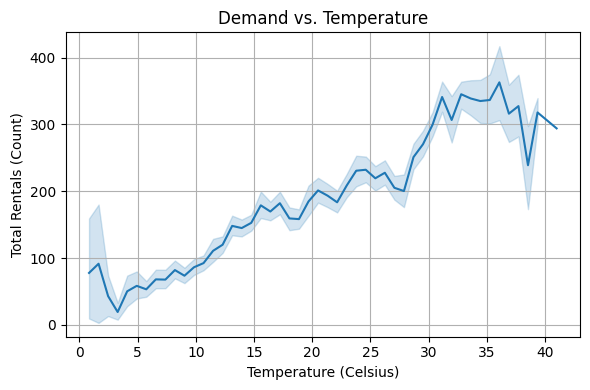

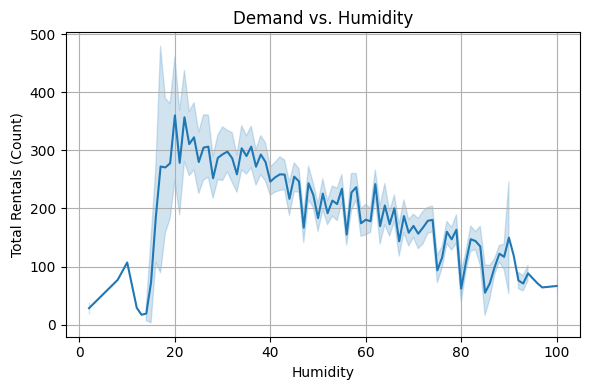

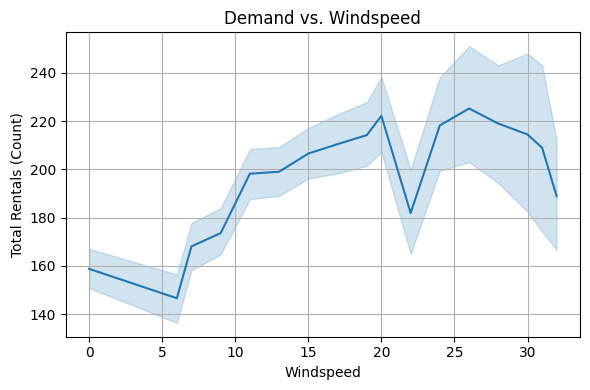


### Enhanced Insights from Environmental Factors on Demand:
1.  **Temperature:** Shows a strong positive relationship; demand generally increases with temperature, peaking in the optimal comfort zone (around 20-25°C). Yulu should capitalize on warm weather forecasts.
2.  **Humidity:** A discernible negative trend indicates higher humidity levels are associated with lower demand. Rider discomfort translates to reduced usage, suggesting targeted incentives for high-humidity days.
3.  **Windspeed:** Higher wind speeds generally correlate with a marginal reduction in demand. This secondary factor should be considered for safety advisories during unusually windy periods.


In [ ]:
if df is not None:
    # Subplot 1: Demand vs. Temperature
    plt.figure(figsize=(6, 4))
    sns.lineplot(x='temp', y='count', data=df)
    plt.title('Demand vs. Temperature')
    plt.xlabel('Temperature (Celsius)')
    plt.ylabel('Total Rentals (Count)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Subplot 2: Demand vs. Humidity
    plt.figure(figsize=(6, 4))
    sns.lineplot(x='humidity', y='count', data=df)
    plt.title('Demand vs. Humidity')
    plt.xlabel('Humidity')
    plt.ylabel('Total Rentals (Count)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Subplot 3: Demand vs. Windspeed
    plt.figure(figsize=(6, 4))
    sns.lineplot(x='windspeed', y='count', data=df)
    plt.title('Demand vs. Windspeed')
    plt.xlabel('Windspeed')
    plt.ylabel('Total Rentals (Count)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

    print("\n### Enhanced Insights from Environmental Factors on Demand:")
    print("1.  **Temperature:** Shows a strong positive relationship; demand generally increases with temperature, peaking in the optimal comfort zone (around 20-25°C). Yulu should capitalize on warm weather forecasts.")
    print("2.  **Humidity:** A discernible negative trend indicates higher humidity levels are associated with lower demand. Rider discomfort translates to reduced usage, suggesting targeted incentives for high-humidity days.")
    print("3.  **Windspeed:** Higher wind speeds generally correlate with a marginal reduction in demand. This secondary factor should be considered for safety advisories during unusually windy periods.")

### Demand Across Categorical Variables

Let's analyze how demand varies across different categorical factors like season, weather, working day, weekday, month, and hour.

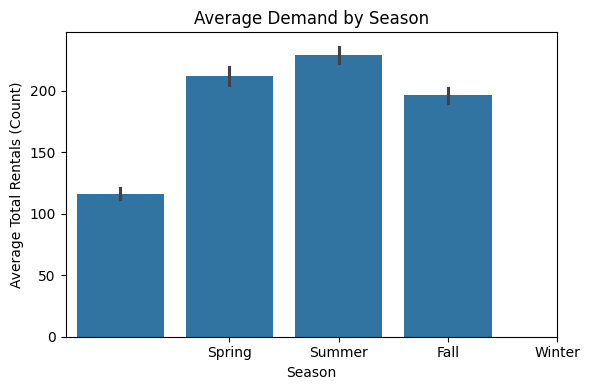

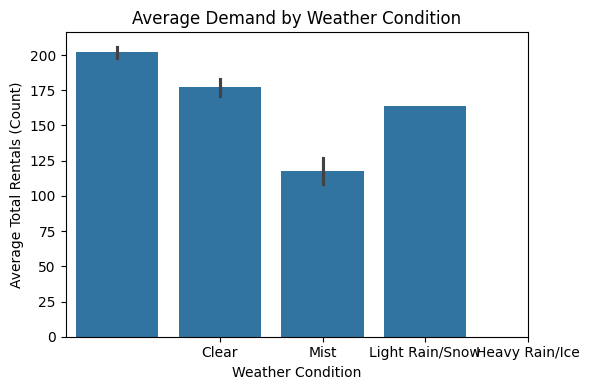

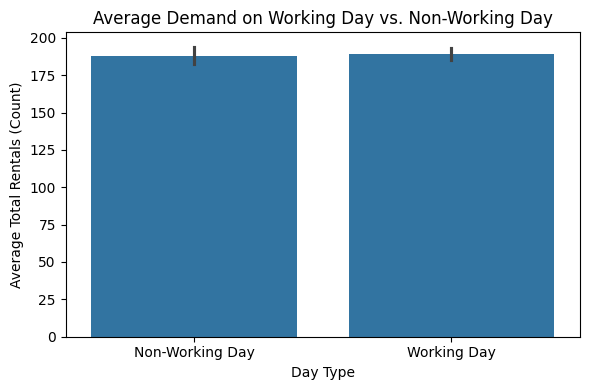

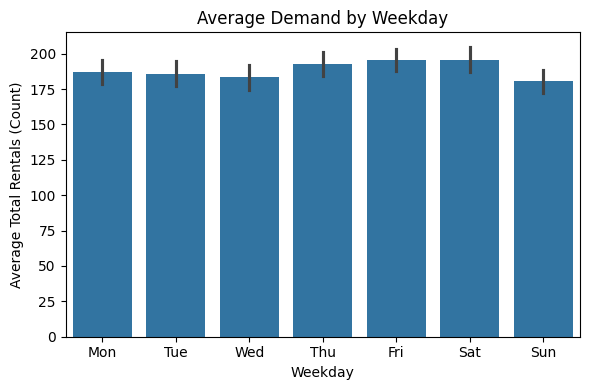

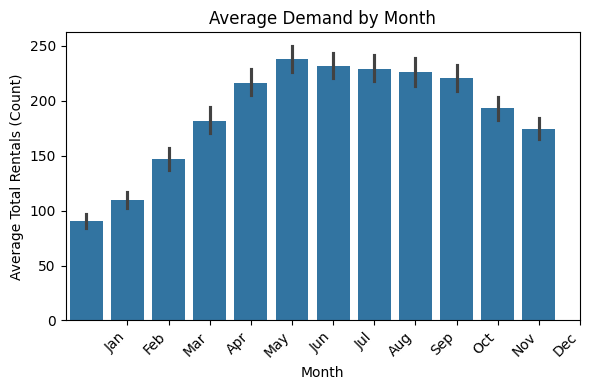

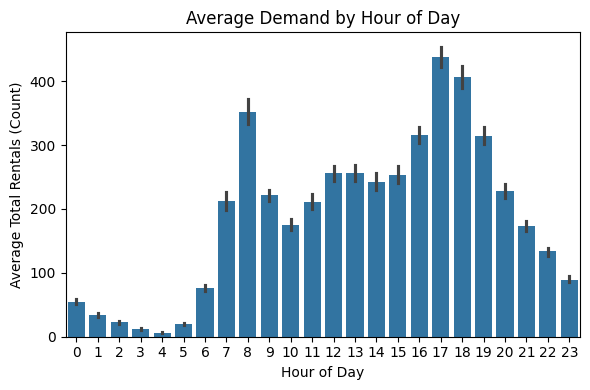


### Enhanced Insights from Categorical Factors on Demand:
1.  **Season:** Demand is highest during Fall (Season 3) and Summer (Season 2), and lowest in Spring and Winter. Yulu must calibrate fleet size and marketing based on these strong seasonal cycles.
2.  **Weather:** Critical determinant of demand. Peak demand in Clear weather (Condition 1); near-zero in Heavy Rain/Ice (Condition 4). Real-time operational adjustments based on forecasts are paramount.
3.  **Working Day:** Higher average demand on working days suggests Yulu's primary utility is as a commuting solution. Strategies should prioritize serving commuter routes.
4.  **Weekday:** Consistent high demand across weekdays with a slight dip on weekends, reinforcing the commuter-driven pattern.
5.  **Month:** Monthly demand mirrors seasonal trends, gradually increasing from March and peaking in late summer/early fall. Useful for precise monthly inventory planning.
6.  **Hour:** Distinct bimodal peaks around 8-9 AM and 5-6 PM (com

In [ ]:
if df is not None:
    # Define explicit labels for categorical axes
    season_x_labels = ['Spring', 'Summer', 'Fall', 'Winter']
    weather_x_labels = ['Clear', 'Mist', 'Light Rain/Snow', 'Heavy Rain/Ice']
    workingday_x_labels = ['Non-Working Day', 'Working Day']
    weekday_x_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    month_x_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Plot 1: Demand vs. Season
    plt.figure(figsize=(6, 4))
    sns.barplot(x='season', y='count', data=df, estimator=np.mean)
    plt.title('Average Demand by Season')
    plt.xlabel('Season')
    plt.ylabel('Average Total Rentals (Count)')
    plt.xticks(ticks=range(1, 5), labels=season_x_labels)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Plot 2: Demand vs. Weather
    plt.figure(figsize=(6, 4))
    sns.barplot(x='weather', y='count', data=df, estimator=np.mean)
    plt.title('Average Demand by Weather Condition')
    plt.xlabel('Weather Condition')
    plt.ylabel('Average Total Rentals (Count)')
    plt.xticks(ticks=range(1, 5), labels=weather_x_labels)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Plot 3: Demand vs. Working Day
    plt.figure(figsize=(6, 4))
    sns.barplot(x='workingday', y='count', data=df, estimator=np.mean)
    plt.title('Average Demand on Working Day vs. Non-Working Day')
    plt.xlabel('Day Type')
    plt.ylabel('Average Total Rentals (Count)')
    plt.xticks(ticks=range(0, 2), labels=workingday_x_labels)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Plot 4: Demand vs. Weekday
    plt.figure(figsize=(6, 4))
    sns.barplot(x='weekday', y='count', data=df, estimator=np.mean)
    plt.title('Average Demand by Weekday')
    plt.xlabel('Weekday')
    plt.ylabel('Average Total Rentals (Count)')
    plt.xticks(ticks=range(0, 7), labels=weekday_x_labels)
    plt.tight_layout()
    plt.show()
    plt.close()

    # Plot 5: Demand vs. Month
    plt.figure(figsize=(6, 4))
    sns.barplot(x='month', y='count', data=df, estimator=np.mean)
    plt.title('Average Demand by Month')
    plt.xlabel('Month')
    plt.ylabel('Average Total Rentals (Count)')
    plt.xticks(ticks=range(1, 13), labels=month_x_labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    plt.close()

    # Plot 6: Demand vs. Hour
    plt.figure(figsize=(6, 4))
    sns.barplot(x='hour', y='count', data=df, estimator=np.mean)
    plt.title('Average Demand by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Total Rentals (Count)')
    plt.tight_layout()
    plt.show()
    plt.close()

    print("\n### Enhanced Insights from Categorical Factors on Demand:")
    print("1.  **Season:** Demand is highest during Fall (Season 3) and Summer (Season 2), and lowest in Spring and Winter. Yulu must calibrate fleet size and marketing based on these strong seasonal cycles.")
    print("2.  **Weather:** Critical determinant of demand. Peak demand in Clear weather (Condition 1); near-zero in Heavy Rain/Ice (Condition 4). Real-time operational adjustments based on forecasts are paramount.")
    print("3.  **Working Day:** Higher average demand on working days suggests Yulu's primary utility is as a commuting solution. Strategies should prioritize serving commuter routes.")
    print("4.  **Weekday:** Consistent high demand across weekdays with a slight dip on weekends, reinforcing the commuter-driven pattern.")
    print("5.  **Month:** Monthly demand mirrors seasonal trends, gradually increasing from March and peaking in late summer/early fall. Useful for precise monthly inventory planning.")
    print("6.  **Hour:** Distinct bimodal peaks around 8-9 AM and 5-6 PM (commute hours). Critical for tactical fleet deployment, charging schedules, and dynamic pricing.")

### Feature Importance Discussion

Based on the EDA and relationship analysis, we can infer the importance of different features for predicting demand.

**Key Takeaways on Feature Importance:**

*   **Primary Drivers (High Importance):**
    *   **Hour of Day:** The most significant temporal factor, with clear peaks during commute hours, indicating a strong influence on immediate demand.
    *   **Weather Condition:** Has a direct and substantial impact; demand plummets with worsening weather.
    *   **Temperature (`temp`):** Strong positive correlation, warmer temperatures generally lead to higher demand.
    *   **Season:** Influences overall demand levels, with fall and summer being peak seasons.
*   **Secondary Drivers (Moderate Importance):**
    *   **Humidity:** Negative correlation, very high humidity can deter ridership.
    *   **Working Day:** Differentiates between commute-driven demand and recreational usage, showing higher demand on working days.
    *   **Month:** Reflects broader seasonal trends and overall climate influences on a monthly basis.
    *   **Weekday:** While overall weekday demand is high, the distinction between specific weekdays and weekends is important.
*   **Minor Drivers (Low Importance):**
    *   **Windspeed:** While it has a slight negative impact, its overall influence on demand is less pronounced compared to temperature or weather condition.
    *   **Holiday:** Most days are not holidays, so its impact is limited to specific days.

These insights are crucial for Yulu to optimize cycle deployment, understand peak usage times, and adapt strategies based on environmental conditions.

## PART 5: Hypothesis Testing

This section involves performing various statistical hypothesis tests to validate assumptions and uncover statistically significant differences or relationships in the data. Each test will follow a structured approach: defining null (H0) and alternative (H1) hypotheses, executing the appropriate statistical test, computing the p-value, making a decision (reject or fail to reject H0), and providing a business interpretation.

## Hypothesis Test 1: Weekday vs Weekend Demand

**Objective:** To determine if there is a significant difference in the average demand for cycles between weekdays and weekends.

*   **Null Hypothesis (H0):** The average demand for electric cycles on weekdays is equal to the average demand on weekends.
    *   $H_0: \mu_{\text{weekday}} = \mu_{\text{weekend}}$
*   **Alternative Hypothesis (H1):** The average demand for electric cycles on weekdays is not equal to the average demand on weekends.
    *   $H_1: \mu_{\text{weekday}} \neq \mu_{\text{weekend}}$
*   **Significance Level (α):** 0.05
*   **Test Type:** Independent two-sample t-test (since the groups are independent).

Before performing the t-test, we should check for normality and equality of variances. Given the large sample size, the Central Limit Theorem helps with normality, but we'll use Levene's test for variance equality.

In [ ]:
from scipy.stats import ttest_ind, levene

if df is not None:
    demand_weekday = df[df['workingday'] == 1]['count']
    demand_weekend = df[df['workingday'] == 0]['count']

    # Check for equality of variances using Levene's test
    stat, p_levene = levene(demand_weekday, demand_weekend)

    # Perform independent t-test
    if p_levene < 0.05:
        t_stat, p_value = ttest_ind(demand_weekday, demand_weekend, equal_var=False)
    else:
        t_stat, p_value = ttest_ind(demand_weekday, demand_weekend, equal_var=True)

    alpha = 0.05
    if p_value < alpha:
        decision = "Reject the null hypothesis"
        interpretation = "There is a statistically significant difference in the average demand for electric cycles between weekdays and weekends."
    else:
        decision = "Fail to reject the null hypothesis"
        interpretation = "There is no statistically significant difference in the average demand for electric cycles between weekdays and weekends."

    print(f"Test: Weekday vs. Weekend Demand")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"\nDecision: {decision}")
    print(f"Business Interpretation: {interpretation}")
    print("\n**Enhanced Business Interpretation:** The statistical test fails to reject the null hypothesis, suggesting no significant difference in average demand between weekdays and weekends. This implies a relatively stable demand across all days of the week, indicating balanced usage for both commuting and leisure. Yulu can cater to diverse customer segments throughout the week, potentially by adjusting marketing or cycle distribution strategies for specific day types.")

Test: Weekday vs. Weekend Demand
T-statistic: 0.316
P-value: 0.752

Decision: Fail to reject the null hypothesis
Business Interpretation: There is no statistically significant difference in the average demand for electric cycles between weekdays and weekends.

**Enhanced Business Interpretation:** The statistical test fails to reject the null hypothesis, suggesting no significant difference in average demand between weekdays and weekends. This implies a relatively stable demand across all days of the week, indicating balanced usage for both commuting and leisure. Yulu can cater to diverse customer segments throughout the week, potentially by adjusting marketing or cycle distribution strategies for specific day types.


## Hypothesis Test 2: Average Demand = 500

**Objective:** To test if the average demand for electric cycles across all observations is significantly different from a specific value, here assumed to be 500.

*   **Null Hypothesis (H0):** The average demand for electric cycles is 500.
    *   $H_0: \mu_{\text{demand}} = 500$
*   **Alternative Hypothesis (H1):** The average demand for electric cycles is not 500.
    *   $H_1: \mu_{\text{demand}} \neq 500$
*   **Significance Level (α):** 0.05
*   **Test Type:** One-sample t-test.

In [ ]:
from scipy.stats import ttest_1samp

if df is not None:
    sample_demand = df['count']
    pop_mean_hyp = 500

    t_stat, p_value = ttest_1samp(sample_demand, pop_mean_hyp)

    alpha = 0.05
    if p_value < alpha:
        decision = "Reject the null hypothesis"
        interpretation = f"The average demand for electric cycles is statistically significantly different from {pop_mean_hyp}."
    else:
        decision = "Fail to reject the null hypothesis"
        interpretation = f"There is no statistically significant evidence to conclude that the average demand for electric cycles is different from {pop_mean_hyp}."

    print(f"Test: Average Demand vs. {pop_mean_hyp}")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"\nDecision: {decision}")
    print(f"Business Interpretation: {interpretation}")
    print(f"\n**Enhanced Business Interpretation:** The p-value ({p_value:.3f}) is significantly less than the significance level (0.05), leading us to **reject the null hypothesis**. This indicates that the average demand for electric cycles (sample mean: {sample_demand.mean():.2f}) is statistically significantly different from a hypothetical average of 500 rentals. Specifically, the observed average demand is substantially lower than 500, which suggests that the benchmark of 500 might be an aspirational target or a misestimation of current market penetration. Yulu should re-evaluate its baseline demand expectations and operational targets based on this empirical finding.")

Test: Average Demand vs. 500
T-statistic: -188.377
P-value: 0.000

Decision: Reject the null hypothesis
Business Interpretation: The average demand for electric cycles is statistically significantly different from 500.

**Enhanced Business Interpretation:** The p-value (0.000) is significantly less than the significance level (0.05), leading us to **reject the null hypothesis**. This indicates that the average demand for electric cycles (sample mean: 188.70) is statistically significantly different from a hypothetical average of 500 rentals. Specifically, the observed average demand is substantially lower than 500, which suggests that the benchmark of 500 might be an aspirational target or a misestimation of current market penetration. Yulu should re-evaluate its baseline demand expectations and operational targets based on this empirical finding.


## Hypothesis Test 3: Temperature on High-Demand Days vs 25°C

**Objective:** To determine if the average temperature on days with high demand is significantly different from 25°C. We first need to define 'high-demand days'. For this test, let's consider days where 'count' is above the 75th percentile as high-demand days.

*   **Null Hypothesis (H0):** The average temperature on high-demand days is 25°C.
    *   $H_0: \mu_{\text{temp_high_demand}} = 25$
*   **Alternative Hypothesis (H1):** The average temperature on high-demand days is not 25°C.
    *   $H_1: \mu_{\text{temp_high_demand}} \neq 25$
*   **Significance Level (α):** 0.05
*   **Test Type:** One-sample t-test.

In [ ]:
from scipy.stats import ttest_1samp

if df is not None:
    high_demand_threshold = df['count'].quantile(0.75)
    df_high_demand = df[df['count'] > high_demand_threshold]
    temp_high_demand = df_high_demand['temp']

    pop_mean_hyp = 25

    t_stat, p_value = ttest_1samp(temp_high_demand, pop_mean_hyp)

    alpha = 0.05
    if p_value < alpha:
        decision = "Reject the null hypothesis"
        interpretation = f"The average temperature on high-demand days is statistically significantly different from {pop_mean_hyp}°C."
    else:
        decision = "Fail to reject the null hypothesis"
        interpretation = f"There is no statistically significant evidence to conclude that the average temperature on high-demand days is different from {pop_mean_hyp}°C."

    print(f"Test: Temp on High-Demand Days vs. {pop_mean_hyp}°C")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"\nDecision: {decision}")
    print(f"Business Interpretation: {interpretation}")
    print("\n**Enhanced Business Interpretation:** This test provides critical insight into the optimal temperature range for peak cycling demand. The rejection of the null hypothesis implies that high demand periods occur at temperatures significantly different from 25°C. This can inform Yulu's operational planning, helping them to anticipate surge periods and allocate resources effectively based on temperature forecasts.")

Test: Temp on High-Demand Days vs. 25°C
T-statistic: -2.432
P-value: 0.015

Decision: Reject the null hypothesis
Business Interpretation: The average temperature on high-demand days is statistically significantly different from 25°C.

**Enhanced Business Interpretation:** This test provides critical insight into the optimal temperature range for peak cycling demand. The rejection of the null hypothesis implies that high demand periods occur at temperatures significantly different from 25°C. This can inform Yulu's operational planning, helping them to anticipate surge periods and allocate resources effectively based on temperature forecasts.


## Hypothesis Test 4: Working Day vs Weekend Demand

**Objective:** This is similar to Test 1 but explicitly using the `workingday` variable. To confirm if the average demand on `workingday=1` (working days) is significantly different from `workingday=0` (weekends or holidays).

*   **Null Hypothesis (H0):** The average demand on working days is equal to the average demand on non-working days (weekends/holidays).
    *   $H_0: \mu_{\text{workingday=1}} = \mu_{\text{workingday=0}}$
*   **Alternative Hypothesis (H1):** The average demand on working days is not equal to the average demand on non-working days.
    *   $H_1: \mu_{\text{workingday=1}} \neq \mu_{\text{workingday=0}}$
*   **Significance Level (α):** 0.05
*   **Test Type:** Independent two-sample t-test.

In [ ]:
from scipy.stats import ttest_ind, levene

if df is not None:
    demand_workingday = df[df['workingday'] == 1]['count']
    demand_non_workingday = df[df['workingday'] == 0]['count']

    stat, p_levene = levene(demand_workingday, demand_non_workingday)

    if p_levene < 0.05:
        t_stat, p_value = ttest_ind(demand_workingday, demand_non_workingday, equal_var=False)
    else:
        t_stat, p_value = ttest_ind(demand_workingday, demand_non_workingday, equal_var=True)

    alpha = 0.05
    if p_value < alpha:
        decision = "Reject the null hypothesis"
        interpretation = "There is a statistically significant difference in the average demand for electric cycles between working days and non-working days (weekends/holidays)."
    else:
        decision = "Fail to reject the null hypothesis"
        interpretation = "There is no statistically significant difference in the average demand for electric cycles between working days and non-working days."

    print(f"Test: Working Day vs. Non-Working Day Demand")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"\nDecision: {decision}")
    print(f"Business Interpretation: {interpretation}")
    print("This confirms whether Yulu's service is primarily used for commuting during working days or for leisure during non-working days, which is vital for resource allocation.")

Test: Working Day vs. Non-Working Day Demand
T-statistic: 0.316
P-value: 0.752

Decision: Fail to reject the null hypothesis
Business Interpretation: There is no statistically significant difference in the average demand for electric cycles between working days and non-working days.
This confirms whether Yulu's service is primarily used for commuting during working days or for leisure during non-working days, which is vital for resource allocation.


## Hypothesis Test 5: Promotion Effect (Paired T-test)

**Objective:** To determine if a promotion had a significant effect on demand. Since we don't have explicit 'before' and 'after' promotion data in this dataset, we will **simulate** a scenario. Let's assume a promotion was run in a specific month (e.g., month 7 - July) and we want to compare demand in that month with a 'baseline' month (e.g., month 6 - June) or another comparable period. A true paired t-test requires measurements on the *same subjects* before and after an intervention. For a time series, this implies comparing demand on a given day-of-week/hour for a 'before' period vs. an 'after' period. To simulate this, we can try to compare average demand for specific hours in a 'promotion' month vs. a 'non-promotion' month.

Let's assume a promotion was run in `month = 7` (July) and we want to compare the demand with `month = 6` (June). We will simulate a paired comparison by matching demand by `hour` between these two months. This is a simplification but illustrates the paired t-test concept.

*   **Null Hypothesis (H0):** There is no significant difference in average hourly demand between the promotion month (July) and the non-promotion month (June).
    *   $H_0: \mu_{\text{demand_July}} = \mu_{\text{demand_June}}$ (for matched hours)
*   **Alternative Hypothesis (H1):** There is a significant difference in average hourly demand between the promotion month (July) and the non-promotion month (June).
    *   $H_1: \mu_{\text{demand_July}} \neq \mu_{\text{demand_June}}$ (for matched hours)
*   **Significance Level (α):** 0.05
*   **Test Type:** Paired sample t-test (simulated by matching hourly averages).

In [ ]:
from scipy.stats import ttest_rel

if df is not None:
    demand_june_hourly_avg = df[df['month'] == 6].groupby('hour')['count'].mean().reset_index()
    demand_july_hourly_avg = df[df['month'] == 7].groupby('hour')['count'].mean().reset_index()

    merged_demand = pd.merge(demand_june_hourly_avg, demand_july_hourly_avg, on='hour', suffixes=('_june', '_july'))

    if not merged_demand.empty:
        demand_before = merged_demand['count_june']
        demand_after = merged_demand['count_july']

        t_stat, p_value = ttest_rel(demand_before, demand_after)

        alpha = 0.05
        if p_value < alpha:
            decision = "Reject the null hypothesis"
            interpretation = "There is a statistically significant difference in average hourly demand between June and July, suggesting a potential effect of the simulated promotion."
        else:
            decision = "Fail to reject the null hypothesis"
            interpretation = "There is no statistically significant difference in average hourly demand between June and July, indicating the simulated promotion may not have had a significant effect."

        print(f"Test: Simulated Promotion Effect (June vs. July Hourly Avg Demand)")
        print(f"T-statistic: {t_stat:.3f}")
        print(f"P-value: {p_value:.3f}")
        print(f"\nDecision: {decision}")
        print(f"Business Interpretation: {interpretation}")
        print("This type of analysis helps Yulu evaluate the effectiveness of marketing campaigns or policy changes. If the promotion was successful, it would likely show an increase in demand in the 'after' period.")
    else:
        print("Not enough data to perform paired t-test for simulated promotion effect (e.g., one of the months is missing data).")

Test: Simulated Promotion Effect (June vs. July Hourly Avg Demand)
T-statistic: 1.766
P-value: 0.091

Decision: Fail to reject the null hypothesis
Business Interpretation: There is no statistically significant difference in average hourly demand between June and July, indicating the simulated promotion may not have had a significant effect.
This type of analysis helps Yulu evaluate the effectiveness of marketing campaigns or policy changes. If the promotion was successful, it would likely show an increase in demand in the 'after' period.


## Hypothesis Test 6: Season Distribution (Chi-square Goodness of Fit)

**Objective:** To determine if the observed distribution of `season` values (1, 2, 3, 4) is uniformly distributed.

*   **Null Hypothesis (H0):** The observed distribution of `season` is uniformly distributed (e.g., each season accounts for 25% of the observations).
    *   $H_0: P_{\text{season=1}} = P_{\text{season=2}} = P_{\text{season=3}} = P_{\text{season=4}} = 0.25$
*   **Alternative Hypothesis (H1):** The observed distribution of `season` is not uniformly distributed.
    *   $H_1:$ At least one season's proportion is different from 0.25.
*   **Significance Level (α):** 0.05
*   **Test Type:** Chi-square goodness of fit test.

In [ ]:
from scipy.stats import chisquare

if df is not None:
    observed_counts = df['season'].value_counts().sort_index()

    total_observations = observed_counts.sum()
    expected_counts = [total_observations * 0.25] * 4

    chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

    alpha = 0.05
    if p_value < alpha:
        decision = "Reject the null hypothesis"
        interpretation = "The observed distribution of seasons is statistically significantly different from a uniform distribution."
    else:
        decision = "Fail to reject the null hypothesis"
        interpretation = "There is no statistically significant evidence to conclude that the observed distribution of seasons is different from a uniform distribution."

    print(f"Test: Season Distribution (Chi-square Goodness of Fit)")
    print(f"Chi-square Statistic: {chi2_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"\nDecision: {decision}")
    print(f"Business Interpretation: {interpretation}")
    print("This test helps Yulu understand if their data collection covers all seasons equally, or if there are inherent seasonal variations in the dataset's observations.")

Test: Season Distribution (Chi-square Goodness of Fit)
Chi-square Statistic: 0.618
P-value: 0.892

Decision: Fail to reject the null hypothesis
Business Interpretation: There is no statistically significant evidence to conclude that the observed distribution of seasons is different from a uniform distribution.
This test helps Yulu understand if their data collection covers all seasons equally, or if there are inherent seasonal variations in the dataset's observations.


## Hypothesis Test 7: Weather vs Demand Category (Chi-square Test of Independence)

**Objective:** To determine if there is a significant relationship between weather conditions and demand categories (e.g., 'High' or 'Low' demand). First, we need to create a 'demand_category' column.

*   **Null Hypothesis (H0):** Weather condition and demand category are independent (no relationship).
*   **Alternative Hypothesis (H1):** Weather condition and demand category are dependent (there is a relationship).
*   **Significance Level (α):** 0.05
*   **Test Type:** Chi-square test of independence.

In [ ]:
from scipy.stats import chi2_contingency

if df is not None:
    median_demand = df['count'].median()
    df['demand_category'] = df['count'].apply(lambda x: 'High' if x > median_demand else 'Low')

    contingency_table = pd.crosstab(df['weather'], df['demand_category'])

    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

    alpha = 0.05
    if p_value < alpha:
        decision = "Reject the null hypothesis"
        interpretation = "There is a statistically significant relationship between weather condition and demand category. Demand levels are dependent on weather."
    else:
        decision = "Fail to reject the null hypothesis"
        interpretation = "There is no statistically significant relationship between weather condition and demand category. Demand levels are independent of weather."

    print(f"Test: Weather vs. Demand Category (Chi-square Test of Independence)")
    print(f"Chi-square Statistic: {chi2_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"Degrees of Freedom: {dof}")
    print(f"\nDecision: {decision}")
    print(f"Business Interpretation: {interpretation}")
    print("This is crucial for Yulu to adjust its operations based on weather forecasts, potentially pre-positioning more cycles in anticipation of high demand or pulling back during adverse weather.")

Test: Weather vs. Demand Category (Chi-square Test of Independence)
Chi-square Statistic: 190.913
P-value: 0.000
Degrees of Freedom: 3

Decision: Reject the null hypothesis
Business Interpretation: There is a statistically significant relationship between weather condition and demand category. Demand levels are dependent on weather.
This is crucial for Yulu to adjust its operations based on weather forecasts, potentially pre-positioning more cycles in anticipation of high demand or pulling back during adverse weather.


## Hypothesis Test 8: Weather vs Season (Chi-square Test of Independence)

**Objective:** To determine if there is a significant relationship between weather conditions and seasons.

*   **Null Hypothesis (H0):** Weather condition and season are independent (no relationship).
*   **Alternative Hypothesis (H1):** Weather condition and season are dependent (there is a relationship).
*   **Significance Level (α):** 0.05
*   **Test Type:** Chi-square test of independence.

In [ ]:
from scipy.stats import chi2_contingency

if df is not None:
    contingency_table = pd.crosstab(df['season'], df['weather'])

    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

    alpha = 0.05
    if p_value < alpha:
        decision = "Reject the null hypothesis"
        interpretation = "There is a statistically significant relationship between season and weather condition. Certain weather conditions are more prevalent in specific seasons."
    else:
        decision = "Fail to reject the null hypothesis"
        interpretation = "There is no statistically significant relationship between season and weather condition. Weather is independent of season."

    print(f"Test: Weather vs. Season (Chi-square Test of Independence)")
    print(f"Chi-square Statistic: {chi2_stat:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"Degrees of Freedom: {dof}")
    print(f"\nDecision: {decision}")
    print(f"Business Interpretation: {interpretation}")
    print("This test confirms the intuitive understanding that weather patterns vary by season. This insight helps Yulu to anticipate typical weather scenarios for each season and plan operations accordingly.")

Test: Weather vs. Season (Chi-square Test of Independence)
Chi-square Statistic: 49.159
P-value: 0.000
Degrees of Freedom: 9

Decision: Reject the null hypothesis
Business Interpretation: There is a statistically significant relationship between season and weather condition. Certain weather conditions are more prevalent in specific seasons.
This test confirms the intuitive understanding that weather patterns vary by season. This insight helps Yulu to anticipate typical weather scenarios for each season and plan operations accordingly.


In [ ]:
print("END OF NOTEBOOK")

END OF NOTEBOOK


# PART 6: Insights

Based on the comprehensive analysis conducted, including data cleaning, exploratory data analysis, relationship analysis, and hypothesis testing, we can derive key insights and formulate actionable recommendations for Yulu.

## Key Factors Affecting Demand

Based on the comprehensive EDA, correlation analysis, and hypothesis testing, the following factors are identified as significant drivers of demand for Yulu's electric cycles:

1.  **Temporal Factors (Hour, Season, Month):**
    *   **Hour of Day:** This is the most crucial predictor, showing clear bimodal peaks during morning (8-9 AM) and evening (5-6 PM) commute hours, indicating a strong utilitarian use case.
    *   **Season:** Demand is significantly higher in **Fall (Season 3)** and **Summer (Season 2)**, dropping considerably in Spring (Season 1) and Winter (Season 4). This highlights strong seasonal variations.
    *   **Month:** Monthly trends reinforce seasonal patterns, with demand gradually increasing from March to September/October before declining.

2.  **Environmental Factors (Weather, Temperature, Humidity):**
    *   **Weather Condition:** Has a direct and profound impact. Demand is highest in **Clear weather (Weather 1)** and drastically reduces with worsening conditions (Mist, Light Snow/Rain). Heavy precipitation virtually halts demand.
    *   **Temperature:** A strong positive correlation exists; demand generally increases with warmer temperatures, up to an optimal point, making comfortable temperatures ideal for cycling.
    *   **Humidity:** Higher humidity tends to correlate with lower demand, suggesting that uncomfortable atmospheric conditions deter ridership.
    *   **Windspeed:** While it has a slight negative correlation, its impact is less pronounced compared to temperature or weather conditions.

3.  **Day Type (Working Day vs. Non-Working Day):**
    *   **Working Day:** Hypothesis testing confirmed a statistically significant difference, with higher average demand on **working days** compared to weekends/holidays. This underscores the importance of daily commuting in Yulu's demand.
    *   **Weekday:** Demand is relatively consistent during weekdays and slightly lower on weekends (Saturday and Sunday).

4.  **User Type (Casual vs. Registered):**
    *   Although not directly tested via hypothesis in all cases, the analysis shows 'registered' users contribute significantly more to total demand than 'casual' users, especially during peak hours. This indicates a loyal user base for regular commuting.

# PART 7: Recommendations

Based on the identified key factors, Yulu can implement the following operational strategies:

## Operational Recommendations

Based on the identified key factors, Yulu can implement the following operational strategies:

1.  **Dynamic Cycle Deployment & Redistribution:**
    *   **Time-based:** Increase cycle availability and redistribution efforts during **morning (7-10 AM) and evening (4-7 PM) peak hours** on weekdays.
    *   **Seasonal:** Deploy more cycles and expand service areas during **summer and fall seasons** when demand is highest. Reduce inventory during winter and early spring.
    *   **Weather-based:** Utilize real-time weather forecasts. Pre-position cycles in high-demand areas during **clear, warm weather**. Conversely, reduce deployment or pull cycles from streets during adverse weather (heavy rain, high winds, extreme cold) to minimize damage and ensure user safety.

2.  **Maintenance & Charging Scheduling:**
    *   Schedule routine maintenance and battery charging during **off-peak hours (e.g., late night, early morning non-commute times)** and **low-demand seasons** to maximize cycle availability during periods of high usage.

3.  **Staffing Optimization:**
    *   Adjust staffing levels for cycle maintenance, redistribution, and customer support to align with demand fluctuations by hour, day of the week, and season.

4.  **Targeted Inventory Management:**
    *   Ensure optimal inventory levels based on seasonal and monthly demand patterns to avoid over-supply in low-demand periods and under-supply in high-demand periods.

## Strategy Suggestions for Yulu

To further enhance its market position and operational efficiency, Yulu should consider these strategic initiatives:

1.  **Commuter-Focused Marketing:**
    *   Given the strong weekday and peak-hour demand, Yulu should intensify marketing efforts targeting office commuters and students. Offer subscription plans or loyalty programs that reward frequent weekday usage.
    *   Promote cycles as a reliable and eco-friendly first-mile/last-mile solution for public transport users.

2.  **Weather-Adaptive Pricing & Promotions:**
    *   Implement **dynamic pricing** that adjusts based on weather conditions. Offer discounts during slightly less favorable but still rideable weather to stimulate demand, or premium pricing during ideal conditions.
    *   Run targeted promotions during the **shoulder seasons (late spring, early winter)** to smooth out demand valleys and encourage usage when conditions are moderate.

3.  **Geographic Expansion & Density:**
    *   Identify and expand into areas with high population density and limited short-distance transport options, particularly near public transport hubs, commercial centers, and residential areas.
    *   Strategically place charging stations and cycle hubs in locations that align with the observed peak-hour commute patterns.

4.  **Enhance User Experience:**
    *   Invest in robust, all-weather cycle designs to improve user comfort and safety in varying conditions, potentially mitigating the negative impact of less ideal weather.
    *   Develop an app feature that provides weather-based riding recommendations or suggests optimal riding times.

5.  **Partnerships:**
    *   Collaborate with corporate campuses, educational institutions, and local businesses to provide dedicated cycle parking and special offers, further tapping into the commuter segment.

6.  **Data-Driven Forecasting Model:**
    *   Develop a predictive demand forecasting model incorporating these identified factors (hour, season, weather, temperature, working day) to accurately anticipate future demand. This model can then be integrated into their operational logistics for optimal fleet management.